In [1]:
import subprocess
import re
from statistics import mean
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": [13, 8], "font.size": 18})

**FIXME: for the "create" case it doesn't make sense to compare the size increase in memory related to the input file size, since there is no input file size**

One of the goals of the cjlib project is ot provide a more memory-efficient and faster CityJSON parsing library, than what could be achieved with a pure python implementation.
Therefore, we use the python's standard [`json` library](https://docs.python.org/3.9/library/json.html) to set a benchmark performance.
The `json` library is an optimized C (CPython) implementation, thus it already provides efficient parsing.

For the comparison against the python implementation we only check the speed and max. memory footprint for parsing a CityJSON file.
Other operations, such as getting a certain CityObject or surface are not important.

The python implementation then becomes:

```python
def parse_python(file: Path):
    with file.resolve().open("r") as fo:
        json.load(fo)
```

In addition to the python standard `json` library, the very efficient [simdjson](https://simdjson.org/) library is also tested.

In [2]:
def run_one(exe, file, architecture, case):
    res = subprocess.run(["/usr/bin/time", "-v", *exe, file, "--architecture", architecture, "--case", case],
                             check=True, capture_output=True)
    mrss = re.search(r"(Maximum resident set size \(kbytes\): )([0-9]+)", res.stderr.decode("utf-8"))
    mut = re.search(r"(User time \(seconds\): )([0-9]+\.[0-9]+)", res.stderr.decode("utf-8"))
    return float(mut[2]), int(mrss[2])

def run_file(exe, exe_py, file: Path, n_iter=10):
    """filename, architecture, case, user_time, max_rss, pct_increase, file_size"""
    architectures = ["direct-json", "vertex-index", "dereference", "python-json", "python-simdjson"]
    #cases = ["deserialize", "geometry", "semantics", "create"]
    cases = ["deserialize", ]
    for a in architectures:
        for c in cases:
            if "python" in a:
                res_iter = [run_one(exe_py[a], file, a, c) for i in range(n_iter)]
            else:
                res_iter = [run_one(exe, file, a, c) for i in range(n_iter)]
            res_ut = sum(i[0] for i in res_iter) / n_iter
            res_rss = round((sum(i[1] for i in res_iter) / n_iter) * 0.001, 2)
            pct_increase = int(round(res_rss / (file.stat().st_size * 0.000001) * 100, 0))
            yield file.stem.replace("_bench.city", ""), a, c, res_ut, res_rss, pct_increase, round(file.stat().st_size * 0.000001, 2)
            
def run_files(exe, exe_py, files):
    for file in files:
        for r in run_file(exe, exe_py, file):
            yield r

In [3]:
bench_files = [
    Path("/home/balazs/Development/cjlib/experiments/data/cluster_bench.city.json"),
    Path("/home/balazs/Development/cjlib/experiments/data/3dbag_v210908_fd2cee53_5786_bench.city.json"),
    Path("/data/3D_basisvoorziening/32cz1_2020_volledig/32cz1_04_bench.city.json")
]
exe = ["/home/balazs/Development/cjlib/experiments/benchmark/target/release/benchmark",]
exe_py = {
    "python-json": ["python3", "/home/balazs/Development/cjlib/experiments/benchmark/src/parse_python.py"],
    "python-simdjson": ["python3", "/home/balazs/Development/cjlib/experiments/benchmark/src/parse_python_simdjson.py"]
}

res_gen = run_files(exe, exe_py, bench_files)
results = pd.DataFrame(data=res_gen, 
                       columns=["filename", "architecture", "case", "user_time_s", 
                                "max_rss_mb", "size_increase_pct", "file_size_mb"])

In [4]:
results

,filename,architecture,case,user_time_s,max_rss_mb,size_increase_pct,file_size_mb
0,cluster,direct-json,deserialize,0.000,3.33,22818,0.01
1,cluster,vertex-index,deserialize,0.000,3.31,22681,0.01
2,cluster,dereference,deserialize,0.000,3.37,23092,0.01
3,cluster,python-json,deserialize,0.017,10.20,69892,0.01
4,cluster,python-simdjson,deserialize,0.019,12.23,83802,0.01
5,3dbag_v210908_fd2cee53_5786,direct-json,deserialize,0.185,52.62,672,7.83
6,3dbag_v210908_fd2cee53_5786,vertex-index,deserialize,0.135,18.90,242,7.83
7,3dbag_v210908_fd2cee53_5786,dereference,deserialize,0.164,33.94,434,7.83
8,3dbag_v210908_fd2cee53_5786,python-json,deserialize,0.271,81.93,1047,7.83
9,3dbag_v210908_fd2cee53_5786,python-simdjson,deserialize,0.229,123.26,1575,7.83


In [5]:
def plot_size_increase(filename):
    ax = (results[results.filename==filename]
              .set_index("architecture")[["case", "size_increase_pct"]]
             .pivot(columns="case", values="size_increase_pct")
             .plot.bar())
    fsize_mb = float(results[results.filename==filename][0:1]["file_size_mb"])
    ax.set_title(f"File: {filename} | {fsize_mb}Mb")
    ax.set_ylabel("Size increase in memory compared to file size [%]")

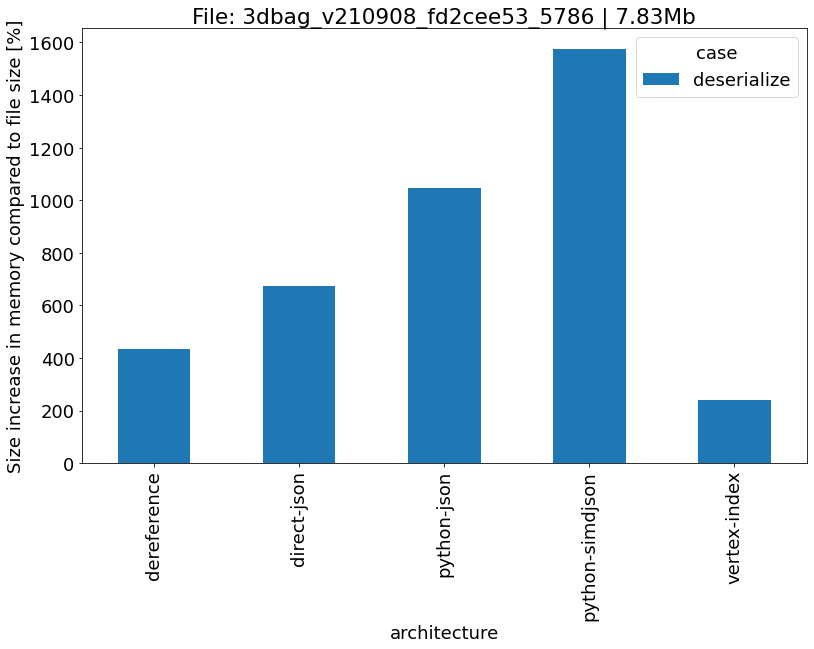

In [6]:
plot_size_increase("3dbag_v210908_fd2cee53_5786")

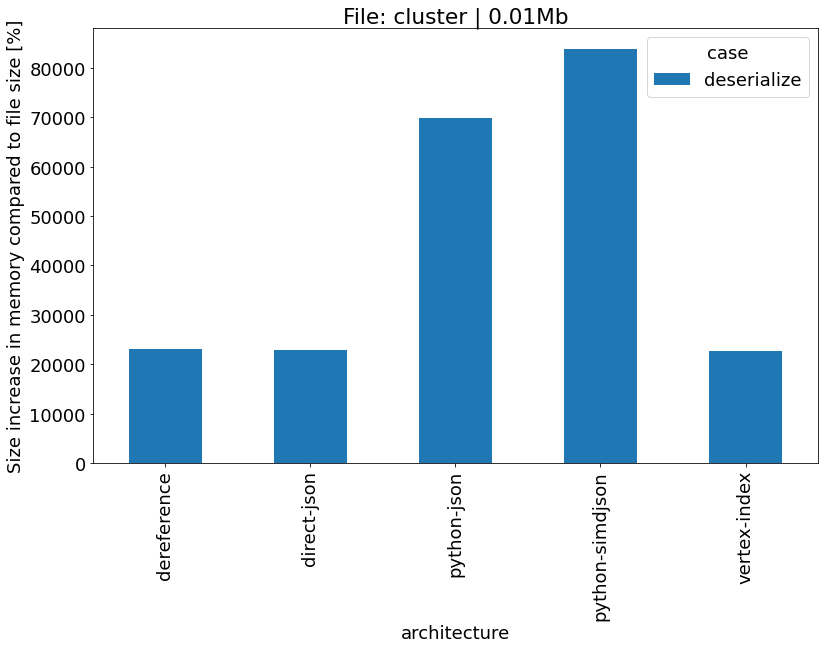

In [7]:
plot_size_increase("cluster")

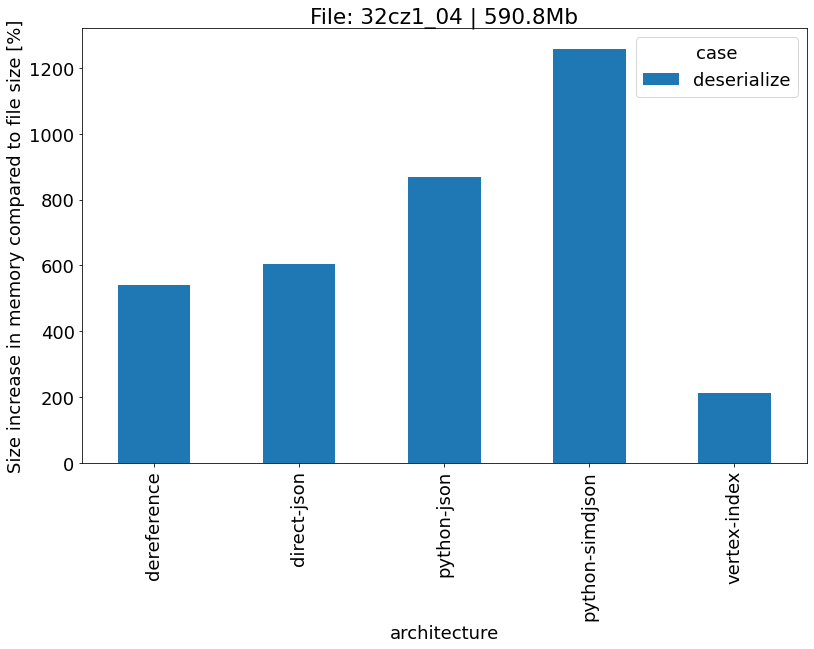

In [8]:
plot_size_increase("32cz1_04")